In [ ]:
# Import libraries
import biom
import pandas as pd
import glob
from biom import Table, example_table
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import birdman.visualization as viz
import birdman.stats as stat
import birdman.diagnostics as diag
import birdman.summary as summary
import arviz as az
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns 
import re
from pca import pca
import numpy as np
plt.style.use('fast')

In [90]:
# Import model results
model = az.from_netcdf("mv_model.nc")

In [93]:
model

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> observed_data

In [ ]:
# Compute summary statistics
diag.r2_score(model)

r2        0.458121
r2_std    0.082278
dtype: float64

: 

In [94]:
# Extract model posterior to dataframe
df = model.posterior[['covariate','feature_alr','beta_var']].to_dataframe()
df = df.groupby(['feature_alr','covariate']).mean().reset_index().pivot(index = 'feature_alr', columns = 'covariate', values = 'beta_var')
df

covariate,ETo,Intercept,Latitude,Precipitation,Rel_Hum,Temp_Max,Temp_Mean,Temp_Min,Vertebrate,Wind
feature_alr,,,,,,,,,,
001842e1fb19c03ad019a34dade74217,-0.007365,-7.519300,0.001503,0.018586,-0.018272,-0.000246,0.001248,-0.014758,-0.023695,-0.014995
0055ede8d7749de1d34ddf2ba14d23d1,-0.020570,-7.516061,0.019674,-0.008646,-0.001408,-0.009272,-0.018342,-0.011407,-0.013559,0.001620
00656e078ca7cd2eece3d8ea0b81817f,0.094579,-7.436149,-0.114558,-0.059999,-0.134599,0.064030,0.033633,0.034688,0.052140,-0.057854
00ac011560ad1b57772ee9dca05cbd75,-0.021337,-7.519996,0.006373,0.003456,0.006033,-0.018591,-0.007790,-0.014820,-0.026110,0.002124
00dc16798fd6ab8a3cd3958f70fb7625,0.019601,-7.498631,0.002478,0.023553,0.028836,0.010072,0.023894,0.032089,0.006448,0.026826
...,...,...,...,...,...,...,...,...,...,...
fe4fb39e24a23d5107beb7215cc986d7,0.050152,-7.487356,-0.011905,-0.025076,-0.043432,0.028211,0.027205,0.003602,0.002761,-0.002859
fe84c0aca183d87b897e6d89c9fee69a,-0.033522,-7.518568,0.019692,0.008273,0.012731,-0.020967,-0.030415,-0.029167,-0.017225,-0.000188
fe89f3b68c9c62344bc992ec7627914f,-0.007416,-7.517483,0.007383,0.011890,-0.011883,-0.003032,0.001713,-0.004355,-0.022474,-0.004780


In [96]:
# Import feature taxonomy
tax = pd.read_csv('Sep_taxonomy.txt', delimiter = '\t')
tax['Phylum'] = tax['Phylum'].apply(lambda x: str(x)[4:]).apply(lambda x: 'Firmicutes' if x[0:10]=='Firmicutes' else x).apply(lambda x: 'Unknown' if x is None else x)
tax.head()

,Feature ID,Domain,Phylum,Class,Order,Family,Genus,Species
0,00003b7926ced7f40416b616ab1ccb04,d__Bacteria,Acidobacteriota,c__Acidobacteriae,o__Acidoferrales,f__UBA7541,g__Acidoferrum,NaN
1,00004539bcbb606c8282f1171595cc59,d__Bacteria,Firmicutes,c__Clostridia_258483,o__Oscillospirales,f__Ruminococcaceae,g__Faecalibacterium,s__Faecalibacterium prausnitzii_C_71351
2,000075b0eed00a9263fa7a183da00f03,d__Bacteria,Bacteroidota,c__Bacteroidia,o__Bacteroidales,f__Muribaculaceae,NaN,NaN
3,0000d1f717323fcf2922031d3db1e7c2,d__Bacteria,Actinobacteriota,c__Acidimicrobiia_401430,o__Acidimicrobiales,NaN,NaN,NaN
4,0000d61eb040fdba90342fb4b5735369,d__Bacteria,Actinobacteriota,c__Actinomycetia,o__Actinomycetales,NaN,NaN,NaN


In [97]:
# Merge differentials and taxonomy
diff = pd.merge(df, tax, left_index = True, right_on = 'Feature ID').set_index(['Domain','Phylum','Class','Order','Family','Genus','Species']).drop(columns = ['Feature ID','Intercept'])
diff

ETo  \
Domain      Phylum           Class                   Order                         Family                        Genus                        Species                                       
d__Bacteria Proteobacteria    c__Gammaproteobacteria  o__Burkholderiales_595422     f__Burkholderiaceae_A_595422  g__Achromobacter            NaN                               -0.007365   
            Cyanobacteria     c__Cyanobacteriia       o__Cyanobacteriales           f__Coleofasciculaceae_23353   g__SIO2C1                    s__SIO2C1 sp010672925            -0.020570   
            Proteobacteria    c__Gammaproteobacteria  o__Enterobacterales_A_737866  f__Enterobacteriaceae_A      NaN                          NaN                                0.094579   
                             NaN                     NaN                           NaN                           NaN                          NaN                               -0.021337   
            Bacteroidota      c__Bacteroidia          o__Bacteroidales              f__Tannerellaceae             g__Parabacteroides_B_862066 NaN                                0.019601   
...                                                                                                                                                                                   ...   
                                                                                    f__Bacteroidaceae             g__Phocaeicola_A_858004      s__Phocaeicola_A_858004 plebeius  0.050152   
            Planctomycetota   c__Planctomycetia       o__Pirellulales               f__Lacipirellulaceae          g__Lacipirellula             s__                              -0.033522   
            Firmicutes        c__Clostridia_258483    o__Oscillospirales            f__Acutalibacteraceae         g__RUG592                    s__RUG592 sp902763835            -0.007416   
            Actinobacteriota NaN                     NaN                           NaN                           NaN                          NaN                               -0.009192   
            Firmicutes        c__Clostridia_258483    o__Lachnospirales             f__Lachnospiraceae           NaN                          NaN                               -0.010070   

                                                                                                                                                                                 Latitude  \
Domain      Phylum           Class                   Order                         Family                        Genus                        Species                                       
d__Bacteria Proteobacteria    c__Gammaproteobacteria  o__Burkholderiales_595422     f__Burkholderiaceae_A_595422  g__Achromobacter            NaN                                0.001503   
            Cyanobacteria     c__Cyanobacteriia       o__Cyanobacteriales           f__Coleofasciculaceae_23353   g__SIO2C1                    s__SIO2C1 sp010672925             0.019674   
            Proteobacteria    c__Gammaproteobacteria  o__Enterobacterales_A_737866  f__Enterobacteriaceae_A      NaN                          NaN                               -0.114558   
                             NaN                     NaN                           NaN                           NaN                          NaN                                0.006373   
            Bacteroidota      c__Bacteroidia          o__Bacteroidales              f__Tannerellaceae             g__Parabacteroides_B_862066 NaN                                0.002478   
...                                                                                                                                                                                   ...   
                                                                                    f__Bacteroidaceae             g__Phocaeicola_A_858004      s__Phocaeicola_A_858004 plebeius -0.011905   
            Planctomyce

In [98]:
# Generate pca dataframe
pca = PCA(n_components=2)
pc_df = pd.DataFrame(data = pca.fit_transform(diff), columns = ['PC1','PC2'])
l = pca.components_.T

In [105]:
# Get explained variance by principal component
exp = pca.explained_variance_ratio_
print('PC1 Explained Variance: ' + str(exp[0]))
print('PC2 Explained Variance: ' + str(exp[1]))

PC1 Explained Variance: 0.496392893122112
PC2 Explained Variance: 0.17611063357047654


In [106]:
# Generate color palette for plot
palette = sns.color_palette("bright", n_colors=10)
palette = palette[0:7] + palette[8:]

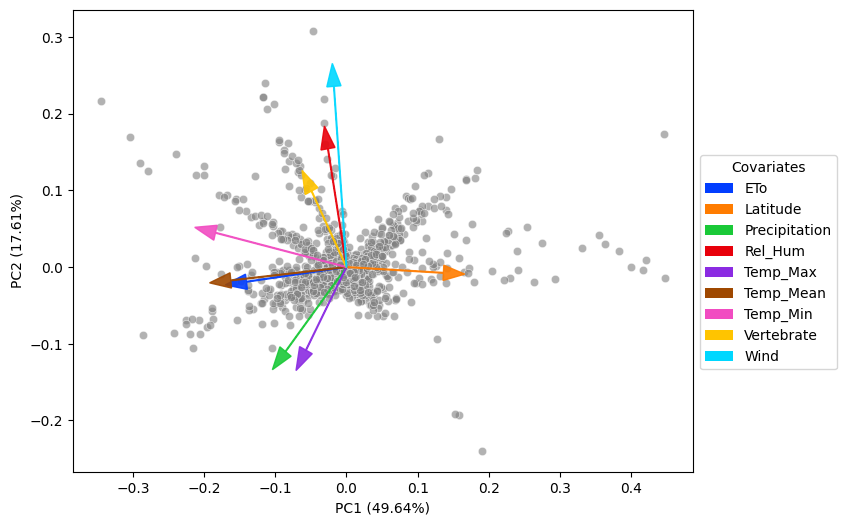

In [107]:
# PCA Biplot not using microbe phylogeny
from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(x = pc_df['PC1'], y = pc_df['PC2'], color = 'gray', alpha = 0.6)
leg_cov = []
for i, feature in enumerate(diff.columns):
    ax.arrow(x=0, y=0, dx=l[i, 0]*0.4, dy=l[i, 1]*0.4, 
             alpha = 0.9,
             head_width = 0.02,  
             edgecolor = palette[i], 
             facecolor = palette[i],
             linestyle = '-',
             length_includes_head = True)
    leg_cov.append(Patch(facecolor = palette[i], label = feature))
plt.xlabel('PC1 (' + str(round(100*exp[0], 2)) + '%)')
plt.ylabel('PC2 (' + str(round(100*exp[1], 2)) + '%)')
ax.legend(
    handles = leg_cov,
    title = 'Covariates',
    bbox_to_anchor = [1.0, 0.7],
    ncol = 1
)


In [108]:
# Generate new color palette
pal = sns.color_palette('husl')
pal[2] = (0.5, 0.5, 0.5)
phy = diff.reset_index()['Phylum']

/tmp/ipykernel_5415/2331716008.py:4: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.scatterplot(x = pc_df['PC1'], y = pc_df['PC2'], color = 'gray', hue = phy.apply(lambda x: x if phy.value_counts()[x] > 100 else 'Other'), palette = pal, alpha = 0.6)


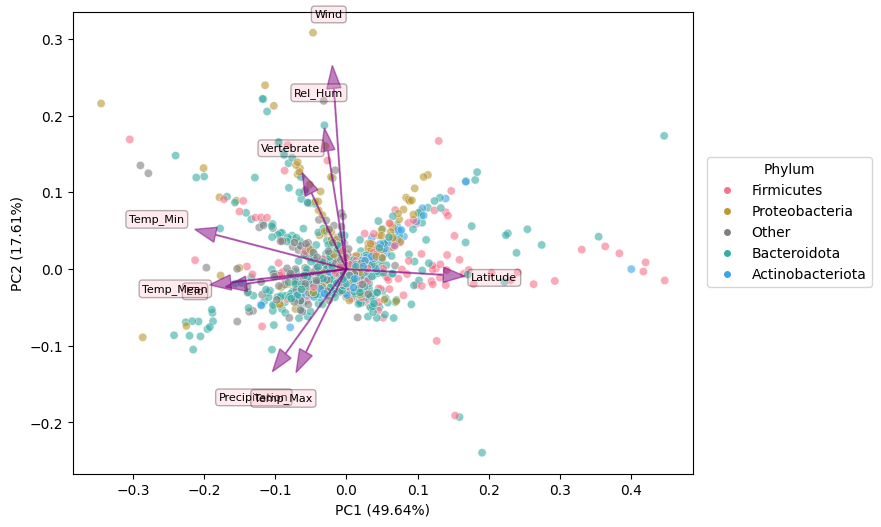

In [111]:
# PCA Biplot with microbe phylogeny
from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(x = pc_df['PC1'], y = pc_df['PC2'], color = 'gray', hue = phy.apply(lambda x: x if phy.value_counts()[x] > 100 else 'Other'), palette = pal, alpha = 0.6)
leg_cov = []
for i, feature in enumerate(diff.columns):
    ax.arrow(x=0, y=0, dx=l[i, 0]*0.4, dy=l[i, 1]*0.4, 
             alpha = 0.5,
             head_width = 0.02,  
             edgecolor = 'purple', 
             facecolor = 'purple',
             linestyle = '-',
             length_includes_head = True,
             label = feature)
    ax.annotate(feature, xy=(l[i, 0]*0.4, l[i, 1]*0.4), xytext=(l[i, 0]*0.5, l[i, 1]*0.5),
        ha='center', va='center', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', fc='pink', alpha=0.3))    
    leg_cov.append(Patch(facecolor = palette[i], label = feature))
plt.xlabel('PC1 (' + str(round(100*exp[0], 2)) + '%)')
plt.ylabel('PC2 (' + str(round(100*exp[1], 2)) + '%)')
ax.legend(
    handles = leg_cov,
    title = 'Covariates',
    bbox_to_anchor = [1.3, 0.7],
    ncol = 1
)
legend_elements = []
for p, col in zip(phy.apply(lambda x: x if phy.value_counts()[x] > 100 else 'Other').value_counts().index, pal):
    legend_elements.append(Line2D([0],[0], marker = 'o', color = 'w', label = p, markerfacecolor = col))
ax.legend(handles = legend_elements, title = 'Phylum', bbox_to_anchor = [1.3, 0.7])
plt.show()

In [112]:
# Group differentials by genus
diff_g = diff.groupby('Genus').mean()
diff_g = diff_g[[ 'ETo','Precipitation', 'Rel_Hum','Temp_Max', 'Temp_Mean', 'Temp_Min', 'Wind']]
diff_g

,ETo,Precipitation,Rel_Hum,Temp_Max,Temp_Mean,Temp_Min,Wind
Genus,,,,,,,
g__,-0.005431,0.014713,-0.000920,-0.001165,0.001438,0.002105,-0.002028
g__1XD42-69,-0.003485,0.014550,-0.007094,-0.004963,-0.007510,-0.002606,-0.009252
g__67-14,-0.012344,0.006331,-0.004563,-0.006493,-0.010224,-0.007860,-0.002663
g__A37T11,-0.009147,0.014967,-0.011454,-0.000449,-0.002389,-0.007239,-0.002829
g__AM51-8,-0.008601,0.011918,-0.005747,0.004122,0.001478,0.006973,-0.011307
...,...,...,...,...,...,...,...
g__Vogesella,-0.004252,0.018241,-0.001116,-0.004322,0.009362,0.007926,-0.008135
g__WRAF01,0.006891,0.022880,0.035463,-0.033090,-0.000570,0.025980,0.084778
g__Weissella_A_338544,-0.013272,0.015807,-0.006975,-0.010443,0.000056,-0.009894,-0.009403


In [113]:
# Group differentials by phylum
diff_p = diff.groupby('Phylum').mean()
diff_p = diff_p[[ 'ETo','Precipitation', 'Rel_Hum','Temp_Max', 'Temp_Mean', 'Temp_Min', 'Wind']]
diff_p

,ETo,Precipitation,Rel_Hum,Temp_Max,Temp_Mean,Temp_Min,Wind
Phylum,,,,,,,
,-0.005727,0.002523,0.005672,-0.011131,-0.002058,0.001274,0.005013
Acidobacteriota,-0.025696,-0.006753,0.011292,-0.016806,-0.020069,-0.004407,0.016732
Actinobacteriota,-0.014007,0.007859,-0.001735,-0.007190,-0.011338,-0.011449,-0.005531
Bacteroidota,0.011740,0.007179,-0.005992,0.005493,0.011294,0.011540,-0.003234
Campylobacterota,0.008566,-0.007948,-0.015937,0.009942,0.004503,0.011517,0.005796
Chlamydiota,-0.003922,0.009722,-0.008289,-0.004541,-0.005097,-0.000812,-0.006687
Chloroflexota,-0.012045,0.010591,-0.003874,-0.006508,-0.009995,-0.010059,-0.003715
Cyanobacteria,-0.014233,0.009515,-0.000685,-0.006457,-0.011635,-0.009876,-0.004103
Deferribacterota,-0.005499,0.044526,-0.012349,-0.003010,-0.004849,-0.010292,-0.018020


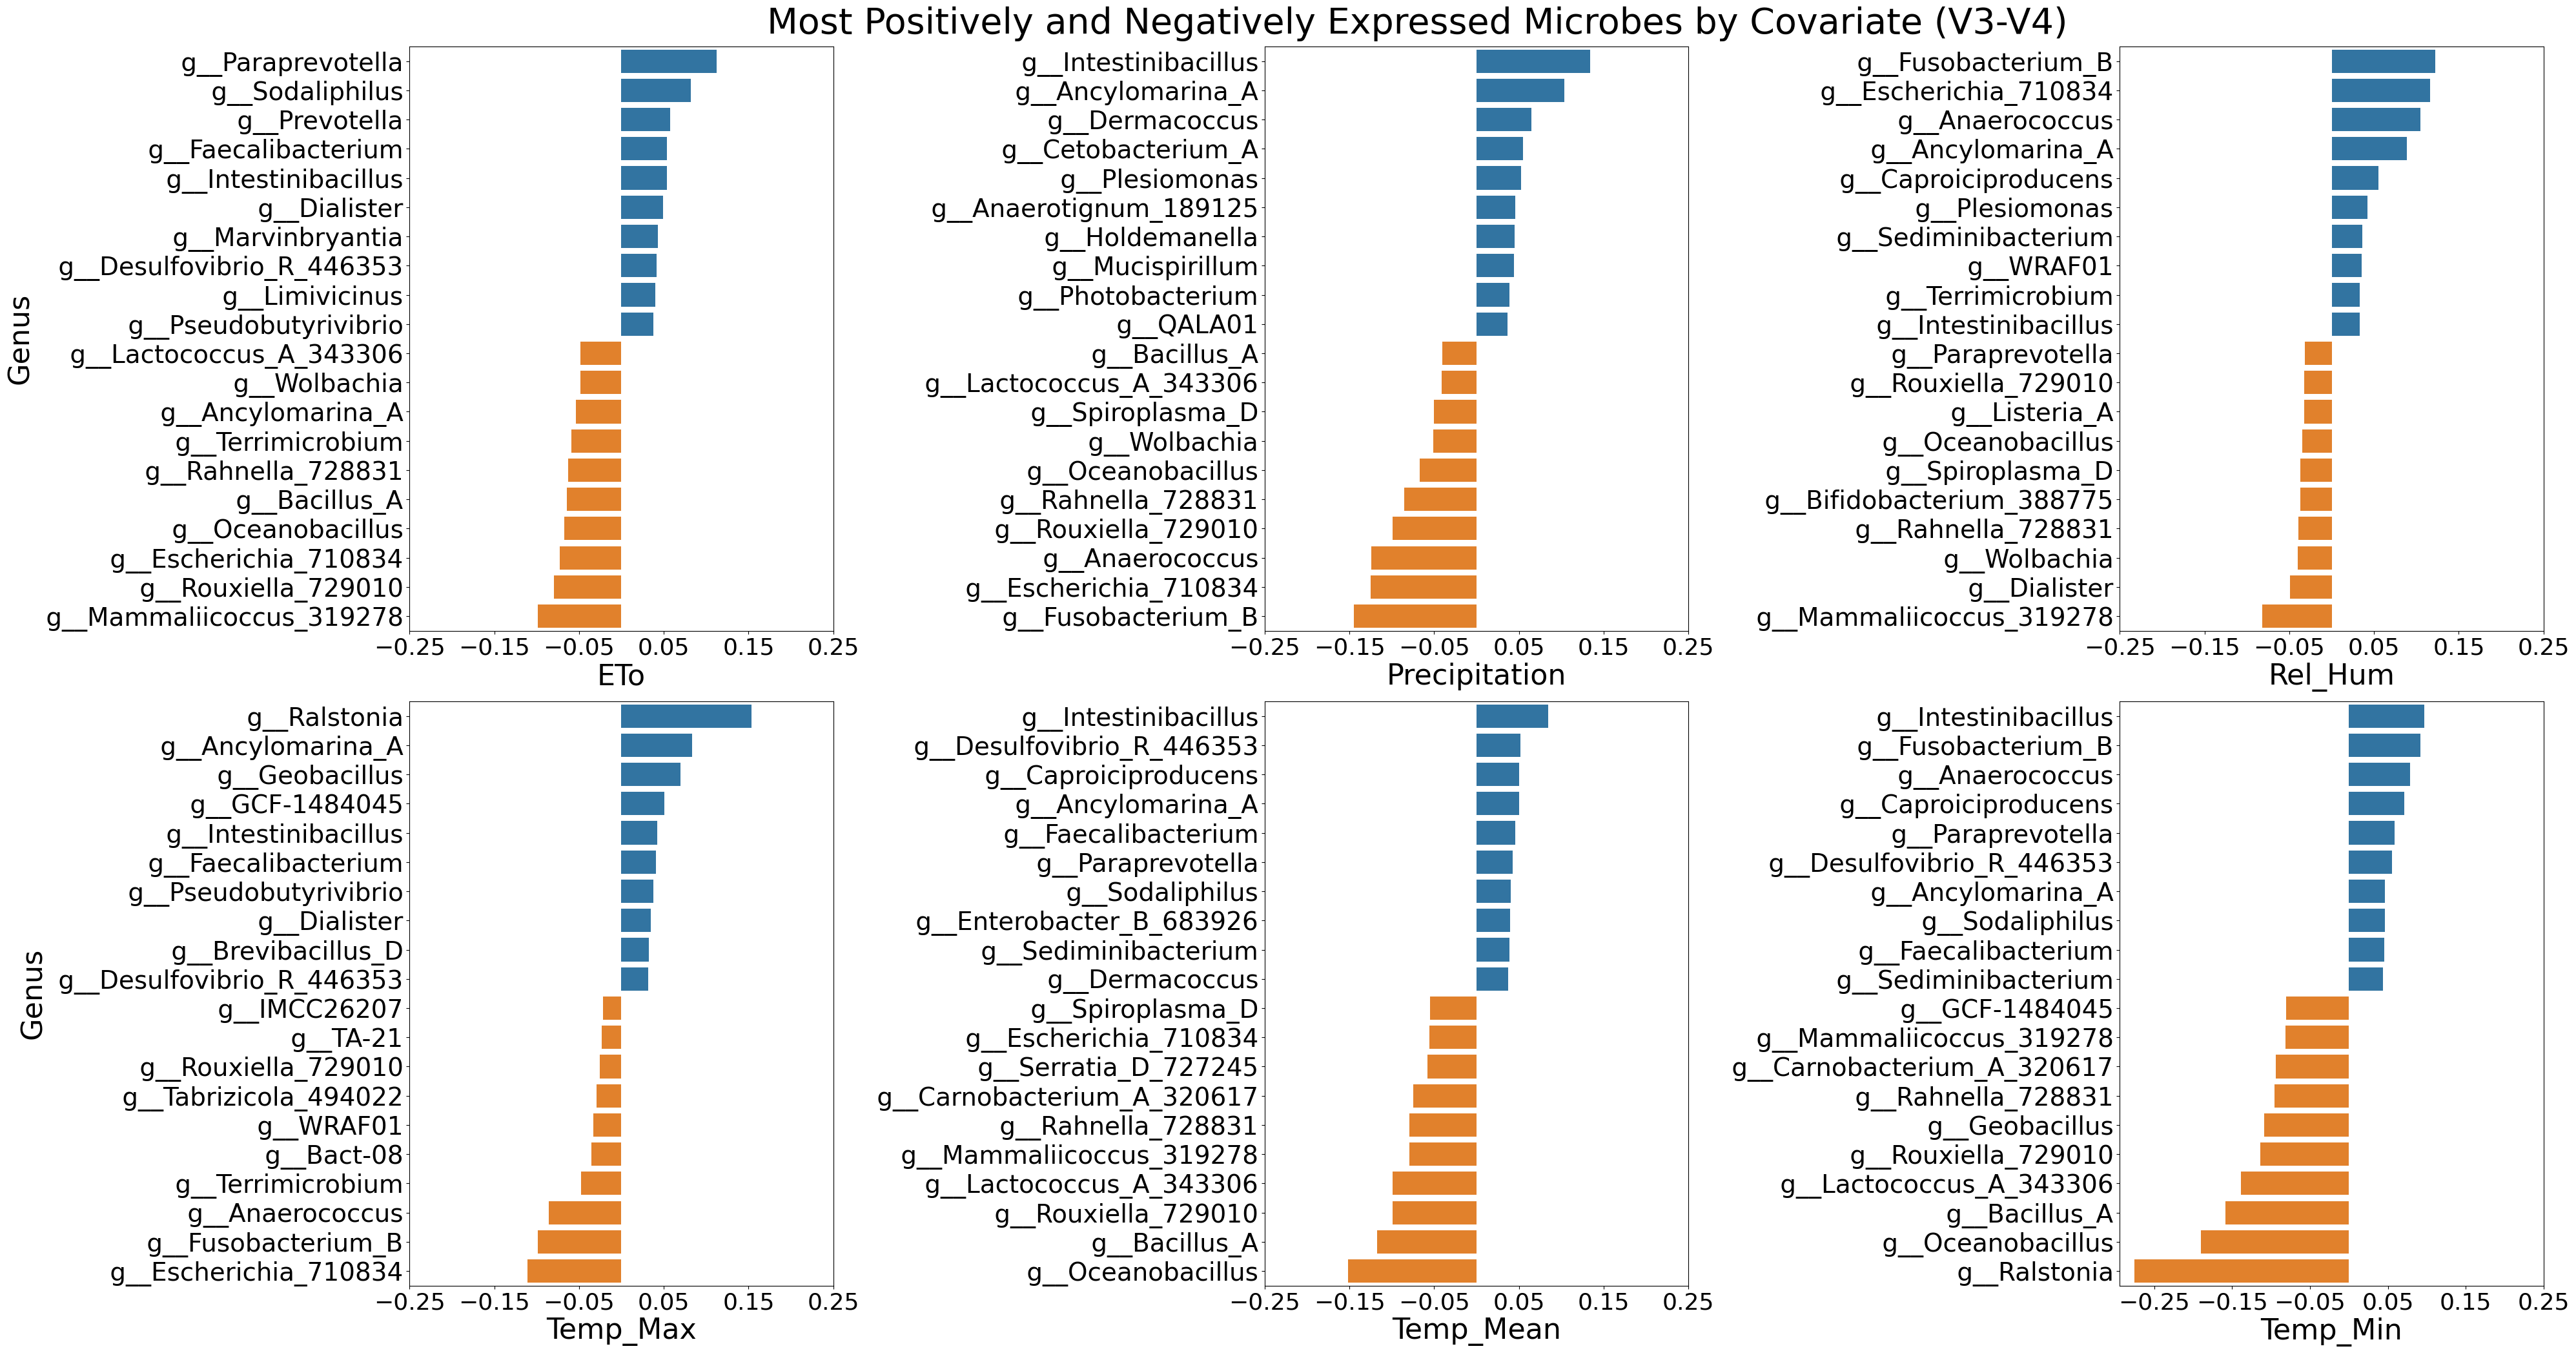

In [ ]:
# Plot 10 most positively and negatively expressed microbes by covariate
fig, axes = plt.subplots(2, 3, figsize=(40, 22))
axes = axes.flatten()
for i, ax in enumerate(axes):
    cov = diff_g.columns[i]
    sns.barplot(x = cov, data = diff_g.sort_values(by=cov, ascending = False).iloc[0:10,:], y = 'Genus', ax = ax)
    sns.barplot(x = cov, data = diff.groupby('Genus').mean().sort_values(by=cov, ascending = True).iloc[0:10,:].sort_values(by=cov, ascending = False), y = 'Genus', ax = ax)
    ax.set_xlabel(cov, fontsize=32)
    ax.set_xticks([-0.25,-0.15,-0.05,0.05,0.15,0.25])
    ax.set_ylabel('Genus', fontsize=32)
    ax.tick_params(axis='y',labelsize=28)
    ax.tick_params(axis='x',labelsize=26)
    if i % 3 != 0:
        ax.set_ylabel('')
plt.suptitle('Most Positively and Negatively Expressed Microbes by Covariate (V3-V4)', x=0.55, y = 0.95, fontsize=40)
plt.tight_layout(rect=[0,0,1,0.96])

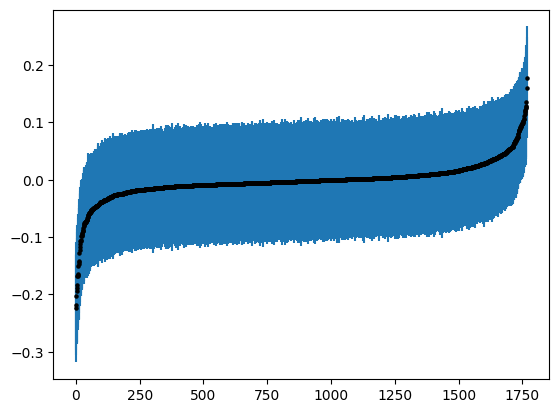

In [ ]:
# Plot parameter estimates of Temp_Mean
import birdman.visualization as viz
ax = viz.plot_parameter_estimates(
    model,
    parameter="beta_var",
    coords={"covariate": "Temp_Mean"},
)


In [ ]:
# Import libraries for identifying significant microbes
from matplotlib_venn import venn3
from upsetplot import UpSet
from filtering_significance import filter_significance
from filtering_significance_phylum import filter_significance_phylum
from filtering_significance_level import filter_significance_level
from collections import Counter

In [120]:
# Process results to dataframe w/ confidence intervals
def process_dataframe(df, feat_id, suffix=""):
        df = df.copy()
        df.reset_index(inplace=True, drop=True)
        df.columns.name = ""
        df.index = feat_id
        df.columns = [x + suffix for x in df.columns]
        return df

def reformat_multiindex(df, feat_id, suffix=""):
    df = df.copy().reset_index()
    new_df = pd.DataFrame(columns=df.covariate.unique(), index=feat_id)
    for c in new_df.columns: 
        lower = df.loc[(df['covariate'] == c) & (df['hdi'] == 'lower')]['beta_var'].values
        higher = df.loc[(df['covariate'] == c) & (df['hdi'] == 'higher')]['beta_var'].values
        new_df[c + '_lower'] = lower
        new_df[c + '_upper'] = higher
    new_df.columns = [c + suffix for c in new_df.columns]
    return new_df


this_feat_id = list(model.posterior['feature_alr'].to_dataframe().index)
this_feat_diff = model.posterior["beta_var"]
this_feat_diff_mean = this_feat_diff.mean(["chain", "draw"]).to_dataframe().reset_index().pivot(index='feature_alr',columns='covariate', values='beta_var')
this_feat_diff_std = this_feat_diff.std(["chain", "draw"]).to_dataframe().reset_index().pivot(index='feature_alr',columns='covariate', values='beta_var')
this_feat_diff_hdi = az.hdi(this_feat_diff, hdi_prob=0.90).to_dataframe()

this_feat_diff_mean = process_dataframe(
this_feat_diff_mean,
this_feat_id,
    suffix="_mean"
)
this_feat_diff_std = process_dataframe(
    this_feat_diff_std,
    this_feat_id,
    suffix="_std"
)
this_feat_diff_hdis = reformat_multiindex(
    this_feat_diff_hdi,
    this_feat_id, 
    suffix='_hdi'
)
interval_df = pd.concat(
    [this_feat_diff_mean, this_feat_diff_std, this_feat_diff_hdis],
    axis=1
)

interval_df.index.name = "Feature"
interval_df

,ETo_mean,Intercept_mean,Latitude_mean,Precipitation_mean,Rel_Hum_mean,Temp_Max_mean,Temp_Mean_mean,Temp_Min_mean,Vertebrate_mean,Wind_mean,...,Precipitation_lower_hdi,Precipitation_upper_hdi,ETo_lower_hdi,ETo_upper_hdi,Rel_Hum_lower_hdi,Rel_Hum_upper_hdi,Wind_lower_hdi,Wind_upper_hdi,Vertebrate_lower_hdi,Vertebrate_upper_hdi
Feature,,,,,,,,,,,,,,,,,,,,,
001842e1fb19c03ad019a34dade74217,-0.007365,-7.519300,0.001503,0.018586,-0.018272,-0.000246,0.001248,-0.014758,-0.023695,-0.014995,...,-0.148604,0.159757,-0.171310,0.154948,-0.186348,0.141090,-0.185356,0.138017,-0.178316,0.124332
0055ede8d7749de1d34ddf2ba14d23d1,-0.020570,-7.516061,0.019674,-0.008646,-0.001408,-0.009272,-0.018342,-0.011407,-0.013559,0.001620,...,-0.191654,0.146206,-0.167105,0.141858,-0.170591,0.174069,-0.148734,0.174957,-0.160208,0.146931
00656e078ca7cd2eece3d8ea0b81817f,0.094579,-7.436149,-0.114558,-0.059999,-0.134599,0.064030,0.033633,0.034688,0.052140,-0.057854,...,-0.220595,0.058830,-0.037397,0.239546,-0.271942,0.011867,-0.195446,0.085288,-0.100675,0.220503
00ac011560ad1b57772ee9dca05cbd75,-0.021337,-7.519996,0.006373,0.003456,0.006033,-0.018591,-0.007790,-0.014820,-0.026110,0.002124,...,-0.150833,0.144889,-0.195227,0.142859,-0.152763,0.189493,-0.143249,0.165741,-0.207979,0.117544
00dc16798fd6ab8a3cd3958f70fb7625,0.019601,-7.498631,0.002478,0.023553,0.028836,0.010072,0.023894,0.032089,0.006448,0.026826,...,-0.130375,0.177693,-0.120989,0.183628,-0.110501,0.192338,-0.113393,0.194460,-0.170439,0.160785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fe4fb39e24a23d5107beb7215cc986d7,0.050152,-7.487356,-0.011905,-0.025076,-0.043432,0.028211,0.027205,0.003602,0.002761,-0.002859,...,-0.163510,0.146804,-0.086204,0.209163,-0.214635,0.114661,-0.164846,0.157748,-0.142299,0.182922
fe84c0aca183d87b897e6d89c9fee69a,-0.033522,-7.518568,0.019692,0.008273,0.012731,-0.020967,-0.030415,-0.029167,-0.017225,-0.000188,...,-0.129131,0.181984,-0.188023,0.143502,-0.144346,0.158202,-0.188141,0.131382,-0.153973,0.136220
fe89f3b68c9c62344bc992ec7627914f,-0.007416,-7.517483,0.007383,0.011890,-0.011883,-0.003032,0.001713,-0.004355,-0.022474,-0.004780,...,-0.159464,0.180019,-0.171405,0.158673,-0.165223,0.138145,-0.153930,0.143934,-0.164862,0.136064


In [122]:
# Merge confidence intervals and taxonomy
conf = pd.merge(interval_df, tax, left_index = True, right_on = 'Feature ID').set_index(['Domain','Phylum','Class','Order','Family','Genus','Species']).drop(columns = ['Feature ID'])
conf

ETo_mean  \
Domain      Phylum           Class                   Order                         Family                        Genus                        Species                                       
d__Bacteria Proteobacteria    c__Gammaproteobacteria  o__Burkholderiales_595422     f__Burkholderiaceae_A_595422  g__Achromobacter            NaN                               -0.007365   
            Cyanobacteria     c__Cyanobacteriia       o__Cyanobacteriales           f__Coleofasciculaceae_23353   g__SIO2C1                    s__SIO2C1 sp010672925            -0.020570   
            Proteobacteria    c__Gammaproteobacteria  o__Enterobacterales_A_737866  f__Enterobacteriaceae_A      NaN                          NaN                                0.094579   
                             NaN                     NaN                           NaN                           NaN                          NaN                               -0.021337   
            Bacteroidota      c__Bacteroidia          o__Bacteroidales              f__Tannerellaceae             g__Parabacteroides_B_862066 NaN                                0.019601   
...                                                                                                                                                                                   ...   
                                                                                    f__Bacteroidaceae             g__Phocaeicola_A_858004      s__Phocaeicola_A_858004 plebeius  0.050152   
            Planctomycetota   c__Planctomycetia       o__Pirellulales               f__Lacipirellulaceae          g__Lacipirellula             s__                              -0.033522   
            Firmicutes        c__Clostridia_258483    o__Oscillospirales            f__Acutalibacteraceae         g__RUG592                    s__RUG592 sp902763835            -0.007416   
            Actinobacteriota NaN                     NaN                           NaN                           NaN                          NaN                               -0.009192   
            Firmicutes        c__Clostridia_258483    o__Lachnospirales             f__Lachnospiraceae           NaN                          NaN                               -0.010070   

                                                                                                                                                                                 Intercept_mean  \
Domain      Phylum           Class                   Order                         Family                        Genus                        Species                                             
d__Bacteria Proteobacteria    c__Gammaproteobacteria  o__Burkholderiales_595422     f__Burkholderiaceae_A_595422  g__Achromobacter            NaN                                     -7.519300   
            Cyanobacteria     c__Cyanobacteriia       o__Cyanobacteriales           f__Coleofasciculaceae_23353   g__SIO2C1                    s__SIO2C1 sp010672925                  -7.516061   
            Proteobacteria    c__Gammaproteobacteria  o__Enterobacterales_A_737866  f__Enterobacteriaceae_A      NaN                          NaN                                     -7.436149   
                             NaN                     NaN                           NaN                           NaN                          NaN                                     -7.519996   
            Bacteroidota      c__Bacteroidia          o__Bacteroidales              f__Tannerellaceae             g__Parabacteroides_B_862066 NaN                                     -7.498631   
...                                                                                                                                                                                         ...   
                                                                                    f__Bacteroidaceae             g__Phocaeicola_A_858004      s__Phocaeicola_A

In [ ]:
# Reset index and aggregate features into one column
conf_reset = conf.reset_index()
conf_reset['Feature'] = conf_reset.apply(
    lambda row: ';'.join(row[:-1].astype(str)), axis=1
)
conf_reset = conf_reset.iloc[:,7:]
conf_reset

,ETo_mean,Intercept_mean,Latitude_mean,Precipitation_mean,Rel_Hum_mean,Temp_Max_mean,Temp_Mean_mean,Temp_Min_mean,Vertebrate_mean,Wind_mean,...,Precipitation_upper_hdi,ETo_lower_hdi,ETo_upper_hdi,Rel_Hum_lower_hdi,Rel_Hum_upper_hdi,Wind_lower_hdi,Wind_upper_hdi,Vertebrate_lower_hdi,Vertebrate_upper_hdi,Feature
0,-0.007365,-7.519300,0.001503,0.018586,-0.018272,-0.000246,0.001248,-0.014758,-0.023695,-0.014995,...,0.159757,-0.171310,0.154948,-0.186348,0.141090,-0.185356,0.138017,-0.178316,0.124332,d__Bacteria;Proteobacteria; c__Gammaproteobact...
1,-0.020570,-7.516061,0.019674,-0.008646,-0.001408,-0.009272,-0.018342,-0.011407,-0.013559,0.001620,...,0.146206,-0.167105,0.141858,-0.170591,0.174069,-0.148734,0.174957,-0.160208,0.146931,d__Bacteria;Cyanobacteria; c__Cyanobacteriia; ...
2,0.094579,-7.436149,-0.114558,-0.059999,-0.134599,0.064030,0.033633,0.034688,0.052140,-0.057854,...,0.058830,-0.037397,0.239546,-0.271942,0.011867,-0.195446,0.085288,-0.100675,0.220503,d__Bacteria;Proteobacteria; c__Gammaproteobact...
3,-0.021337,-7.519996,0.006373,0.003456,0.006033,-0.018591,-0.007790,-0.014820,-0.026110,0.002124,...,0.144889,-0.195227,0.142859,-0.152763,0.189493,-0.143249,0.165741,-0.207979,0.117544,d__Bacteria;;nan;nan;nan;nan;nan;-0.0213367116...
4,0.019601,-7.498631,0.002478,0.023553,0.028836,0.010072,0.023894,0.032089,0.006448,0.026826,...,0.177693,-0.120989,0.183628,-0.110501,0.192338,-0.113393,0.194460,-0.170439,0.160785,d__Bacteria;Bacteroidota; c__Bacteroidia; o__B...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1763,0.050152,-7.487356,-0.011905,-0.025076,-0.043432,0.028211,0.027205,0.003602,0.002761,-0.002859,...,0.146804,-0.086204,0.209163,-0.214635,0.114661,-0.164846,0.157748,-0.142299,0.182922,d__Bacteria;Bacteroidota; c__Bacteroidia; o__B...
1764,-0.033522,-7.518568,0.019692,0.008273,0.012731,-0.020967,-0.030415,-0.029167,-0.017225,-0.000188,...,0.181984,-0.188023,0.143502,-0.144346,0.158202,-0.188141,0.131382,-0.153973,0.136220,d__Bacteria;Planctomycetota; c__Planctomycetia...
1765,-0.007416,-7.517483,0.007383,0.011890,-0.011883,-0.003032,0.001713,-0.004355,-0.022474,-0.004780,...,0.180019,-0.171405,0.158673,-0.165223,0.138145,-0.153930,0.143934,-0.164862,0.136064,d__Bacteria;Firmicutes; c__Clostridia_258483; ...
1766,-0.009192,-7.510601,0.003655,0.015185,-0.000990,-0.001176,-0.013706,-0.006652,-0.029272,-0.013860,...,0.150733,-0.163028,0.168238,-0.149890,0.160629,-0.180201,0.137679,-0.180724,0.141673,d__Bacteria;Actinobacteriota;nan;nan;nan;nan;n...


In [ ]:
# Filter to identify statistically significant microbes
col_order = conf_reset.columns[0:len(model.posterior.covariate.data)]
col_order = [s[:-5] for s in col_order]
col_order

top_negative = {}
top_positive = {}
sig = {}

for i,cov in enumerate(col_order):
    
    sig[cov], top_positive[cov], top_negative[cov] = filter_significance(conf_reset,column=i, top_40=False)

Test column: ETo
Total features before filtering: 1768
Significant features: 6
250     0.119780
532     0.056767
738    -0.300345
1036    0.124373
1225    0.004633
1657   -0.345969
Name: lower_hdi, dtype: float64
Top Features: 4
Bottom Features: 2
Test column: Intercept
Total features before filtering: 1768
Significant features: 1768
0      -7.66940
1      -7.68736
2      -7.61739
3      -7.70793
4      -7.65712
         ...   
1763   -7.66548
1764   -7.67834
1765   -7.69043
1766   -7.69211
1767   -7.66305
Name: lower_hdi, Length: 1768, dtype: float64
Top Features: 0
Bottom Features: 1768
Test column: Latitude
Total features before filtering: 1768
Significant features: 17
27      0.041346
587    -0.264911
670    -0.334333
674     0.025132
738     0.090843
903     0.059465
907     0.025995
1033   -0.316236
1089    0.059925
1094   -0.292735
1163   -0.284721
1196    0.044112
1291   -0.275407
1657    0.049679
1674   -0.325039
1682   -0.339432
1722   -0.323704
Name: lower_hdi, dtype: float6

In [126]:
def significance_by_level(level):
    col_order = conf_reset.columns[0:len(model.posterior.covariate.data)]
    col_order = [s[:-5] for s in col_order]
    col_order

    top_negative = {}
    top_positive = {}
    sig = {}

    column_to_move = level
    level_conf = conf.groupby(level).mean().reset_index()
    level_conf = level_conf[[col for col in level_conf.columns if col != column_to_move] + [column_to_move]]

    for i,cov in enumerate(col_order):
        
        sig[cov], top_positive[cov], top_negative[cov] = filter_significance_level(level_conf,column=i, top_40=False, level=level)
    return sig, top_positive, top_negative

In [ ]:
# Calculate significance at species level
s, t, n = significance_by_level('Species')

Test column: ETo
Total features before filtering: 245
Significant features: 0
Series([], Name: lower_hdi, dtype: float64)
Top Features: 0
Bottom Features: 0
Test column: Intercept
Total features before filtering: 245
Significant features: 245
0     -7.671243
1     -7.678250
2     -7.678423
3     -7.687040
4     -7.720090
         ...   
240   -7.659090
241   -7.685790
242   -7.638550
243   -7.661110
244   -7.648130
Name: lower_hdi, Length: 245, dtype: float64
Top Features: 0
Bottom Features: 245
Test column: Latitude
Total features before filtering: 245
Significant features: 0
Series([], Name: lower_hdi, dtype: float64)
Top Features: 0
Bottom Features: 0
Test column: Precipitation
Total features before filtering: 245
Significant features: 1
131   -0.329006
Name: lower_hdi, dtype: float64
Top Features: 0
Bottom Features: 1
Test column: Rel_Hum
Total features before filtering: 245
Significant features: 1
131    0.022232
Name: lower_hdi, dtype: float64
Top Features: 1
Bottom Features: 0
T

In [ ]:
# Count significant microbes by covariate
for key, value in sig.items():
    print([key, value.shape[0]])

['ETo', 6]
['Intercept', 1768]
['Latitude', 17]
['Precipitation', 15]
['Rel_Hum', 2]
['Temp_Max', 1]
['Temp_Mean', 13]
['Temp_Min', 19]
['Vertebrate', 3]
['Wind', 12]


[' g__Paraprevotella', ' g__Sodaliphilus', ' g__Prevotella', ' g__Faecalibacterium', ' g__Intestinibacillus', ' g__Dialister', ' g__Marvinbryantia', ' g__Desulfovibrio_R_446353', ' g__Limivicinus', ' g__Pseudobutyrivibrio', ' g__Lactococcus_A_343306', ' g__Wolbachia', ' g__Ancylomarina_A', ' g__Terrimicrobium', ' g__Rahnella_728831', ' g__Bacillus_A', ' g__Oceanobacillus', ' g__Escherichia_710834', ' g__Rouxiella_729010', ' g__Mammaliicoccus_319278']
[' g__Intestinibacillus', ' g__Ancylomarina_A', ' g__Dermacoccus', ' g__Cetobacterium_A', ' g__Plesiomonas', ' g__Anaerotignum_189125', ' g__Holdemanella', ' g__Mucispirillum', ' g__Photobacterium', ' g__QALA01', ' g__Bacillus_A', ' g__Lactococcus_A_343306', ' g__Spiroplasma_D', ' g__Wolbachia', ' g__Oceanobacillus', ' g__Rahnella_728831', ' g__Rouxiella_729010', ' g__Anaerococcus', ' g__Escherichia_710834', ' g__Fusobacterium_B']
[' g__Fusobacterium_B', ' g__Escherichia_710834', ' g__Anaerococcus', ' g__Ancylomarina_A', ' g__Caproiciprodu

/tmp/ipykernel_5415/2336228705.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cur_y_ticks)
/tmp/ipykernel_5415/2336228705.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cur_y_ticks)
/tmp/ipykernel_5415/2336228705.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cur_y_ticks)


[' g__Ralstonia', ' g__Ancylomarina_A', ' g__Geobacillus', ' g__GCF-1484045', ' g__Intestinibacillus', ' g__Faecalibacterium', ' g__Pseudobutyrivibrio', ' g__Dialister', ' g__Brevibacillus_D', ' g__Desulfovibrio_R_446353', ' g__IMCC26207', ' g__TA-21', ' g__Rouxiella_729010', ' g__Tabrizicola_494022', ' g__WRAF01', ' g__Bact-08', ' g__Terrimicrobium', ' g__Anaerococcus', ' g__Fusobacterium_B', ' g__Escherichia_710834']
[' g__Intestinibacillus', ' g__Desulfovibrio_R_446353', ' g__Caproiciproducens', ' g__Ancylomarina_A', ' g__Faecalibacterium', ' g__Paraprevotella', ' g__Sodaliphilus', ' g__Enterobacter_B_683926', ' g__Sediminibacterium', ' g__Dermacoccus', ' g__Spiroplasma_D', ' g__Escherichia_710834', ' g__Serratia_D_727245', ' g__Carnobacterium_A_320617', ' g__Rahnella_728831', ' g__Mammaliicoccus_319278', ' g__Lactococcus_A_343306', ' g__Rouxiella_729010', ' g__Bacillus_A', ' g__Oceanobacillus']
[' g__Intestinibacillus', ' g__Fusobacterium_B', ' g__Anaerococcus', ' g__Caproiciproduc

/tmp/ipykernel_5415/2336228705.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cur_y_ticks)
/tmp/ipykernel_5415/2336228705.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cur_y_ticks)
/tmp/ipykernel_5415/2336228705.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cur_y_ticks)


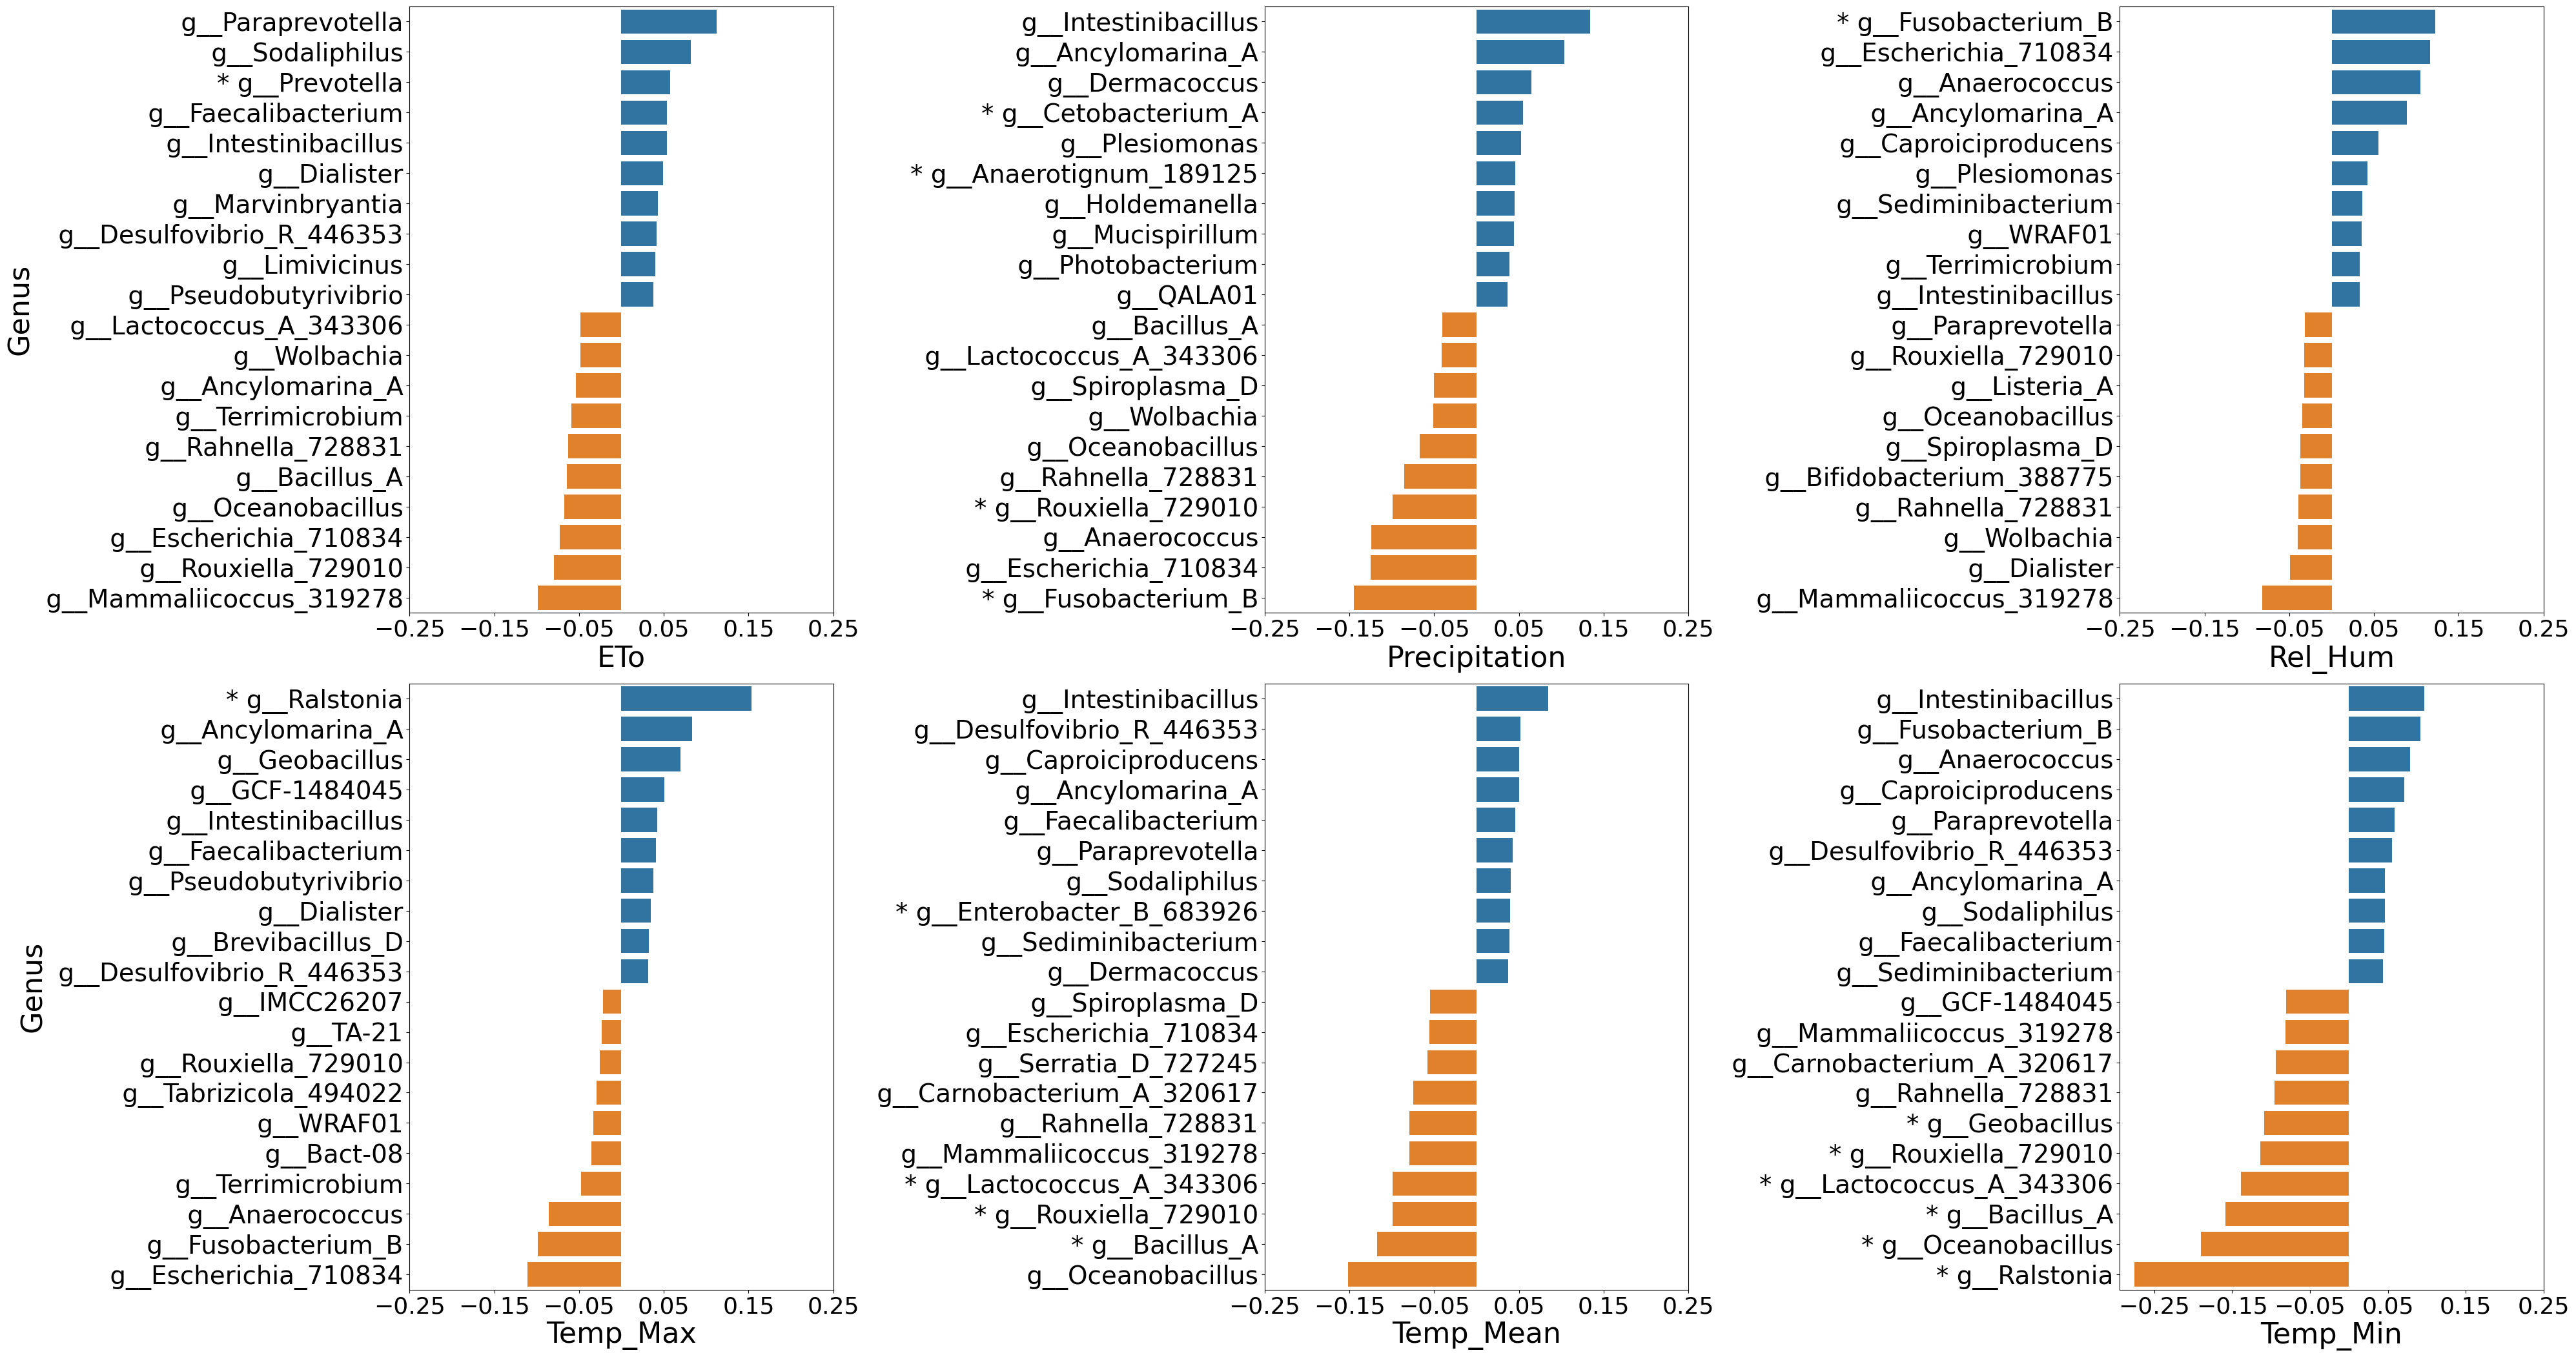

In [ ]:
# Plot 10 most positively and negatively expressed microbes by covariate w/ statistically significant microbes
fig, axes = plt.subplots(2, 3, figsize=(40, 22))
axes = axes.flatten()
for i, ax in enumerate(axes):
    cov = diff_g.columns[i]
    sns.barplot(x = cov, data = diff_g.sort_values(by=cov, ascending = False).iloc[0:10,:], y = 'Genus', ax = ax)
    sns.barplot(x = cov, data = diff.groupby('Genus').mean().sort_values(by=cov, ascending = True).iloc[0:10,:].sort_values(by=cov, ascending = False), y = 'Genus', ax = ax)
    ax.set_xlabel(cov, fontsize=32)
    ax.set_xticks([-0.25,-0.15,-0.05,0.05,0.15,0.25])
    ax.set_ylabel('Genus', fontsize=32)
    ax.tick_params(axis='y',labelsize=28)
    ax.tick_params(axis='x',labelsize=26)
    cur_y_ticks = ax.get_yticklabels()
    cur_y_ticks = genus_names = [label.get_text() for label in cur_y_ticks]
    print(cur_y_ticks)
    for j, genus in enumerate(cur_y_ticks):
        if any(sig[cov]['Genus'].str.contains(genus)):
            cur_y_ticks[j] = '*' + genus
    ax.set_yticklabels(cur_y_ticks)
    if i % 3 != 0:
        ax.set_ylabel('')
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [ ]:
# Reformat stat sig microbes into features dictionary
features = {}

for cov in model.posterior.covariate.data:
    features[cov] = {}
    features[cov]['top'] = top_positive[cov]['Feature']
    features[cov]['bottom'] = top_negative[cov]['Feature']

/home/akommala/miniconda3/envs/birdman/lib/python3.12/site-packages/matplotlib_venn/layout/venn3/pairwise.py:107: UserWarning: Circle B has zero area.
  warnings.warn("Circle B has zero area.")


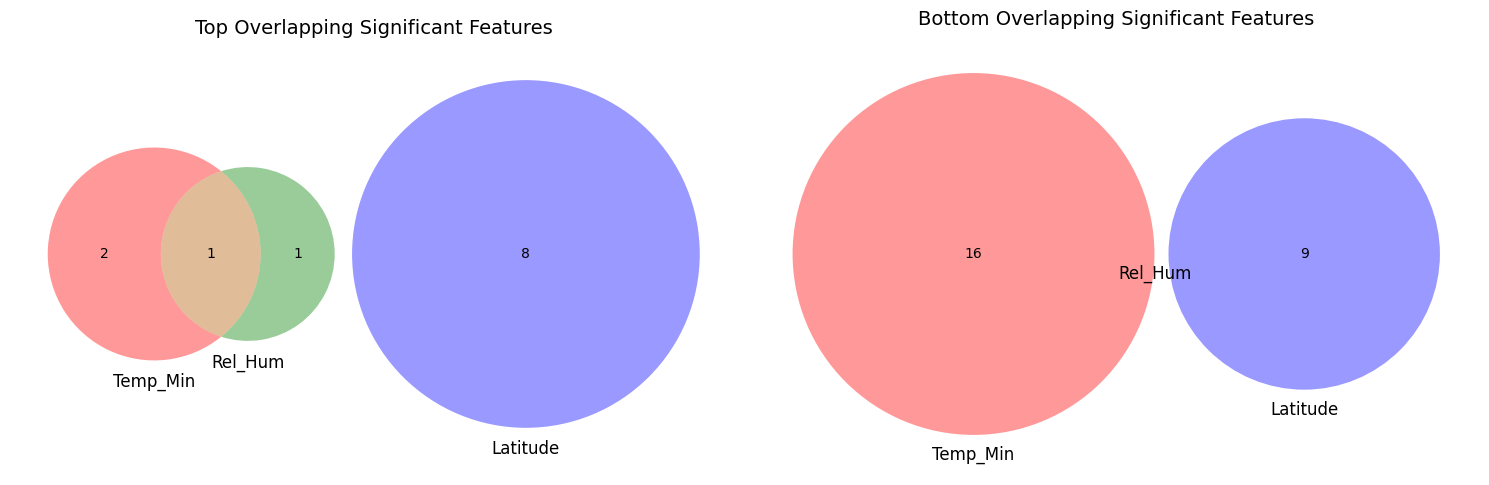

In [ ]:
# Visualize significant microbe overlap by variable
fig, axs = plt.subplots(1, 2, figsize=(15, 5))  # Adjust figsize as needed
covs = ['Temp_Min','Rel_Hum','Latitude']
for j, feature_type in enumerate(['top', 'bottom']):
    # Access the subplot for the current level and feature type
    ax = axs[j]

    feat_sets = []
    for i in range(len(covs)):
        feat_sets.append(set(features[covs[i]][feature_type]))


    # Create the Venn diagram on the selected subplot
    venn_diagram = venn3(feat_sets,
                        set_labels=covs,
                         ax=ax)

    # Adjust the fontsize of outer set labels
    '''for label in venn_diagram.set_labels:
        label.set_fontsize(12)

        venn_labels = {
            #'100': set_dementia - set_amyloid - set_apoe4,
            #'010': set_amyloid - set_dementia - set_apoe4,
            #'001': set_apoe4 - set_dementia - set_amyloid,
            #'110': set_dementia & set_amyloid - set_apoe4,
            #'101': set_dementia & set_apoe4 - set_amyloid,
            #'011': set_amyloid & set_apoe4 - set_dementia,
            #'111': set_dementia & set_amyloid & set_apoe4
        }

        # Set initial position offsets
    offsets = {
        '100': (-0.04, 0),
        '010': (0, 0),
        '001': (0, -.015),
        '110': (0, -0.02),
        '101': (-0.02, .02),
        '011': (0, 0),
        '111': (0.02, 0)
    }

    for label_id, microbes in venn_labels.items():
        label = venn_diagram.get_label_by_id(label_id)
        if label:
            offset_x, offset_y = offsets[label_id]
            label.set_text('\n'.join(microbes))
            label.set_fontsize(8)
            label.set_x(label.get_position()[0] + offset_x)
            label.set_y(label.get_position()[1] + offset_y)
    '''        

    ax.set_title(f"{feature_type.capitalize()} Overlapping Significant Features", fontsize=14)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the entire figure
plt.show()

In [ ]:
# Collect significant microbes by Phylum
bact_feat = interval_df.index[interval_df.index.isin(tax[tax['Phylum'] == 'Bacteroidota']['Feature ID'])]
firm_feat = interval_df.index[interval_df.index.isin(tax[tax['Phylum'] == 'Firmicutes']['Feature ID'])]
act_feat = interval_df.index[interval_df.index.isin(tax[tax['Phylum'] == 'Actinobacteriota']['Feature ID'])]